In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import joblib
from sklearn.base import clone

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer

from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.util import Surv
from sksurv.metrics import concordance_index_ipcw,integrated_brier_score

Reading in the full dataset, splitting out columns into categories, and dropping columns that are not needed to create the dataset I'll use for the model:

In [2]:
hospitals_full = pd.read_csv('../data/hospitals_full.csv')

In [3]:
model_data = hospitals_full.drop(columns=['State', 'Zip', 'County','Facility Name','Closed', 'Closure Date','Full Address', 'Prior Name','Tract_Code', 'CBSA_Code', 'CBSA_Title','County_FIPS', 'State_FIPS'])


In [4]:
model_data.shape

(34609, 190)

In [5]:
model_data.head()

,Year,CCN,"Donations, Land Improvements",NUMBER OF BEDS: Total Hospital,BALANCE SHEET: Total Current Assets (G_C1THRU4_11),Total Bad Debt expense,"RECONCILIATION OF CAPITAL COST CENTERS: Depreciation, Total (A7_3_C9_3)",BALANCE SHEET: Inventory (G_C1THRU4_7),BALANCE SHEET: Cash on Hand and in Banks (G_C1THRU4_1),Net Revenue from Medicaid,...,Per Capita Short Term Gen Hosp Admissions,Per Capita Short Term General Hosp Beds,Per Capita Total Active D.O.s Non-Federal,Per Capita Total Active M.D.s Non-Federal,Per Capita Total Medicare Inpatient Days Short Term General Hospitals,Per Capita Total Number Hospitals,Percent Persons in Poverty,Population Estimate,"Unemployment Rate, 16+",Time
0,2010,190034,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.054363,0.001638,0.0,0.000707,0.170210,0.000034,17.5,57999.0,7.2,15
1,2011,190034,NaN,44.0,1.818425e+07,7.459345e+06,2.315905e+06,1.049677e+06,1.338600e+06,1.329145e+07,...,0.044856,0.001630,0.0,0.000721,0.135510,0.000034,19.2,58276.0,6.6,15
2,2012,190034,NaN,44.0,2.015527e+07,7.461412e+06,2.401758e+06,1.187828e+06,1.196731e+05,8.956364e+06,...,0.040342,0.001618,0.0,0.000834,0.110859,0.000034,17.4,58723.0,5.5,15
3,2013,190034,NaN,44.0,1.866968e+07,8.374215e+06,2.432267e+06,1.138573e+06,8.277853e+05,9.529077e+06,...,0.045078,0.001603,0.0,0.000726,0.134204,0.000034,18.6,59253.0,NaN,15
4,2014,190034,NaN,44.0,1.811909e+07,8.911561e+06,2.616684e+06,1.165749e+06,1.442356e+06,1.016856e+07,...,0.046447,0.001594,0.0,0.000671,0.124178,0.000034,18.3,59616.0,5.6,15


#### Exploratory Data Analysis:

How are hospital closures distributed across the years?

In [6]:
hospitals_full['Closure Date'] = pd.to_datetime(hospitals_full['Closure Date'])

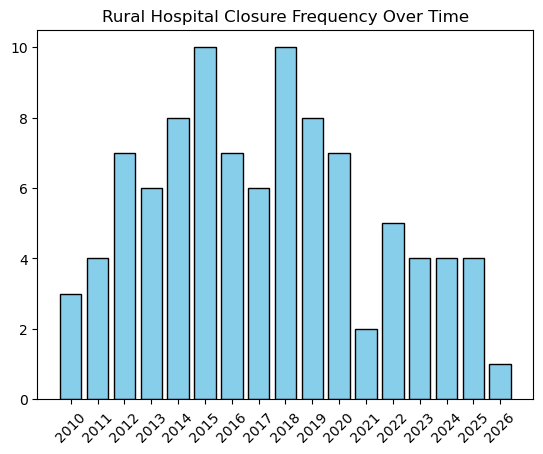

In [7]:
closure_years = hospitals_full[~hospitals_full['Closure Date'].isna()]['Closure Date'].unique().year

# Count the frequency of each year
year_counts = Counter(closure_years)

# Sort by year so the x-axis is chronological
sorted_years = sorted(year_counts.keys())
frequencies = [year_counts[year] for year in sorted_years]

# Create the plot
plt.bar(sorted_years, frequencies, color='skyblue', edgecolor='black');
plt.title('Rural Hospital Closure Frequency Over Time');
plt.xticks([i for i in range(2010,2027)], rotation=45)
plt.savefig("../app/images/closure_plot.png")

Dropping features with low variance:

In [8]:
model_data['Emergency Services'].value_counts()

Emergency Services
Yes    30423
No      3216
Name: count, dtype: int64

Seeing if there is a trend with missing value frequency over time.

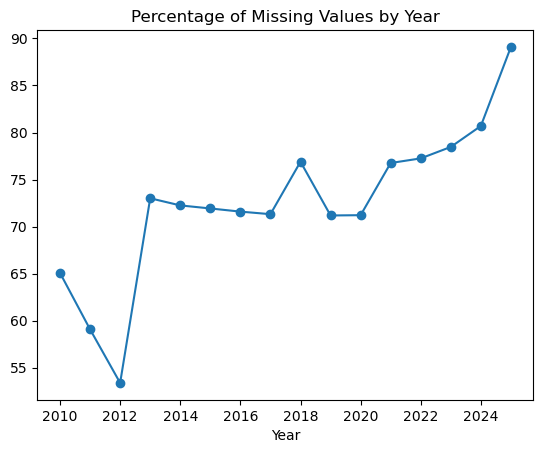

In [9]:
years = model_data['Year']
nan_percentages_all = model_data.drop(columns=['Year']).isna().groupby(years).mean() * 100
nan_percentages = nan_percentages_all.mean(axis=1)
nan_percentages.plot(kind='line',marker='o')
plt.title('Percentage of Missing Values by Year');

Looking at percentage of NaN values per year for a single column per feature type (financial, quality, demographic)

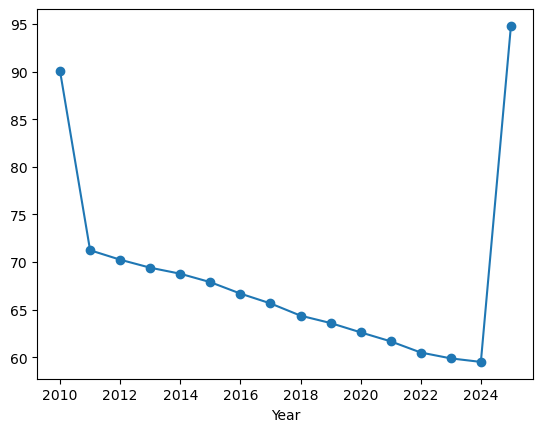

In [10]:
(model_data.groupby('Year')['Financial Indicators: Cash Reserves'].apply(lambda x: x.isna().mean() * 100)).plot(kind='line', marker='o');

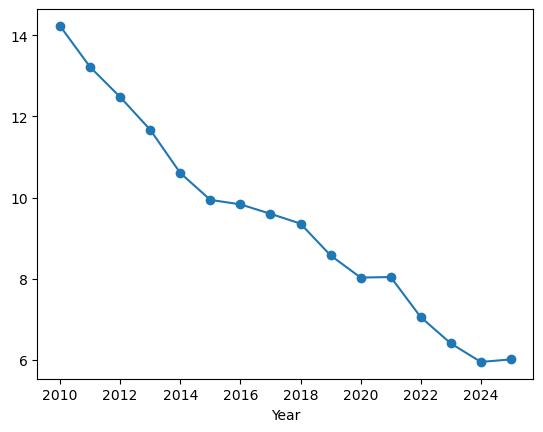

In [11]:
(model_data.groupby('Year')['clean_score'].apply(lambda x: x.isna().mean() * 100)).plot(kind='line', marker='o');

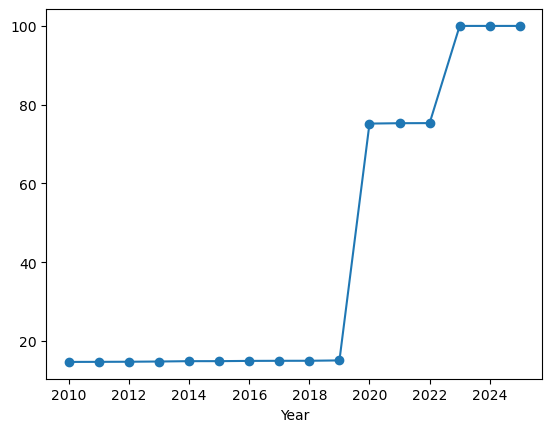

In [12]:
(model_data.groupby('Year')['% <65 without Health Insurance'].apply(lambda x: x.isna().mean() * 100)).plot(kind='line', marker='o');

In [13]:
model_data[model_data['Year']>=2022].isna().mean().sort_values(ascending=False)

scipinf6_denom    1.0
ami8_share        1.0
op6_share         1.0
ami10_denom       1.0
op1_denom         1.0
                 ... 
CCN               0.0
Status            0.0
Metro_Status      0.0
RUCA              0.0
Time              0.0
Length: 190, dtype: float64

In [14]:
model_data[model_data['Year']<2022].isna().mean().sort_values(ascending=False)

ami_readm_npatients    1.0
hk_readm_npatients     1.0
ami_readm_rate         1.0
hf_mort_rate           1.0
hf_readm_rate          1.0
                      ... 
CCN                    0.0
Status                 0.0
Metro_Status           0.0
RUCA                   0.0
Time                   0.0
Length: 190, dtype: float64

#### Feature Engineering:

Simplifying Hospital Type column into 'Government','Non-Profit', and 'For-Profit':

In [15]:
replace_mapping = {
    # Government groupings
    'Government - Hospital District or Authority': 'Government',
    'Governmental-Hospital District': 'Government',
    'Government - Federal': 'Government',
    'Governmental- Federal': 'Government',
    'Government - Local': 'Government',
    'Government - State': 'Government',
    'Governmental-County': 'Government',
    'Governmental-City': 'Government',
    'Governmental-City-County': 'Government',
    'Governmental-Other': 'Government',
    'Tribal': 'Government',
    
    # Voluntary / Non-profit groupings
    'Voluntary non-profit - Private': 'Non-Profit',
    'Voluntary Nonprofit-Other': 'Non-Profit',
    'Voluntary non-profit - Other': 'Non-Profit',
    'Voluntary non-profit - Church': 'Non-Profit',
    'Voluntary Nonprofit-Church': 'Non-Profit',
    
    # Proprietary groupings
    'Proprietary, Corporation': 'For-Profit',
    'Proprietary-Corporation': 'For-Profit',
    'Proprietary, Partnership': 'For-Profit',
    'Proprietary-Partnership': 'For-Profit',
    'Proprietary-Individual': 'For-Profit',
    'Proprietary, Other': 'For-Profit',
    'Physician': 'For-Profit'
}

model_data['Hospital Type'] = model_data['Hospital Type'].replace(replace_mapping)


In [16]:
# Fill empty hospital types with the most common hospital type. This would not be data leakage since this information does not change over time.
most_common = model_data['Hospital Type'].mode()[0]

# Fill the NaN values
model_data['Hospital Type'] = model_data['Hospital Type'].fillna(most_common)


In [17]:
# Fill empty emergency services with the most common value. This would not be data leakage since this information does not change over time.
most_common = model_data['Emergency Services'].mode()[0]

# Fill the NaN values
model_data['Emergency Services'] = model_data['Emergency Services'].fillna(most_common)

In [18]:
pd.set_option('display.max_rows', None)
model_data.isnull().mean().sort_values(ascending=False)

ami_readm_npatients                                                        1.000000
hk_readm_npatients                                                         1.000000
ami_readm_rate                                                             1.000000
hf_mort_rate                                                               1.000000
hf_readm_rate                                                              1.000000
pn_mort_rate                                                               1.000000
pn_readm_rate                                                              1.000000
ami_mort_npatients                                                         1.000000
hf_mort_npatients                                                          1.000000
hf_readm_npatients                                                         1.000000
pn_mort_npatients                                                          1.000000
pn_readm_npatients                                                         1

Drop columns that are more than 80% NaNs

In [19]:
model_data = model_data.loc[:, model_data.isnull().mean() <= 0.80]

What columns are left after dropping columns that are more than 80% null?

We lose pretty much all of the process of care scores, mortality and readmission data, as well as the following financial data:
Financial Indicators: SOLVENCY Interest Coverage Ratio                     
TRIAL BALANCE OF EXPENSE ACCOUNTS: Interest Expense (A_C2_113)             
FTE Employees on Payroll  
HAC reduction adjustment amount                                            
BALANCE SHEET: Temporary Investments (G_C1THRU4_2)
REIMBURSEMENT SETTLEMENT: Payment to cost ratio                            
Donations, Land Improvements      

In [20]:
model_data.shape

(34609, 92)

Looking at distributions of numeric features to see what type of imputation is appropriate:

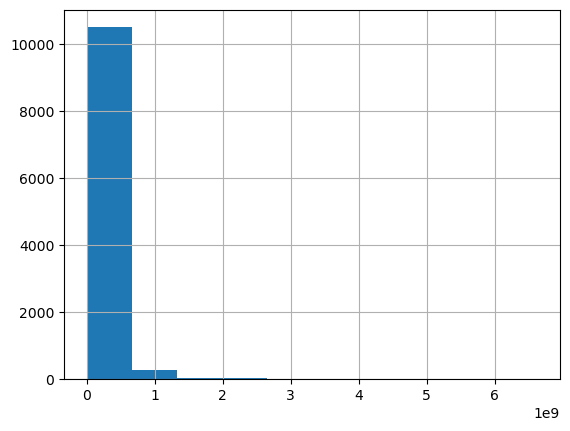

In [21]:
model_data['Financial Indicators: Cash Reserves'].hist();

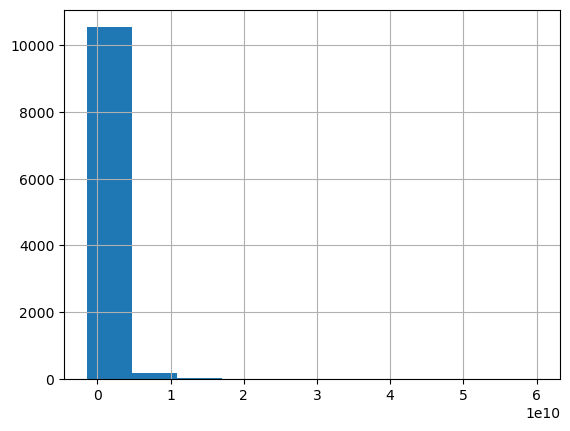

In [22]:
model_data['BALANCE SHEET: Total Assets (G_C1THRU4_36)'].hist();

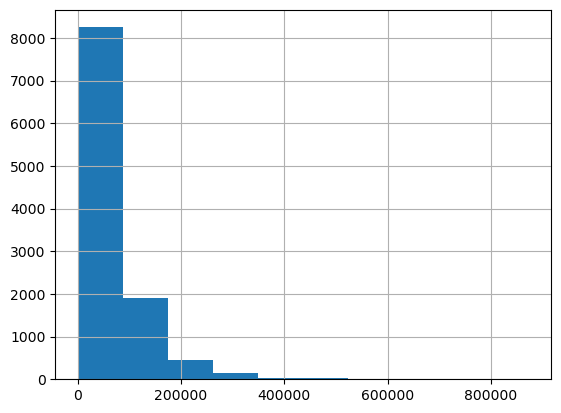

In [23]:
model_data['Total Inpatient Days'].hist();

The numeric variables seem to be very right skewed, so a median imputation would be appropriate.

Are there any hospitals that we don't have any data for?

In [24]:
model_data[model_data.isna().all(axis=1)]

,Year,CCN,NUMBER OF BEDS: Total Hospital,BALANCE SHEET: Total Current Assets (G_C1THRU4_11),Total Bad Debt expense,"RECONCILIATION OF CAPITAL COST CENTERS: Depreciation, Total (A7_3_C9_3)",BALANCE SHEET: Inventory (G_C1THRU4_7),BALANCE SHEET: Cash on Hand and in Banks (G_C1THRU4_1),Net Revenue from Medicaid,Total Charges,...,Per Capita Short Term Gen Hosp Admissions,Per Capita Short Term General Hosp Beds,Per Capita Total Active D.O.s Non-Federal,Per Capita Total Active M.D.s Non-Federal,Per Capita Total Medicare Inpatient Days Short Term General Hospitals,Per Capita Total Number Hospitals,Percent Persons in Poverty,Population Estimate,"Unemployment Rate, 16+",Time


For every hospital in the dataset, we have at least some financial data, quality data, and/or demographic data.

Ensuring all of the data types are appropriate for the values they represent:

In [25]:
model_data.dtypes

Year                                                                         int64
CCN                                                                          int64
NUMBER OF BEDS: Total Hospital                                             float64
BALANCE SHEET: Total Current Assets (G_C1THRU4_11)                         float64
Total Bad Debt expense                                                     float64
RECONCILIATION OF CAPITAL COST CENTERS: Depreciation, Total (A7_3_C9_3)    float64
BALANCE SHEET: Inventory (G_C1THRU4_7)                                     float64
BALANCE SHEET: Cash on Hand and in Banks (G_C1THRU4_1)                     float64
Net Revenue from Medicaid                                                  float64
Total Charges                                                              float64
BALANCE SHEET: Accounts Receivable (G_C1THRU4_4)                           float64
IPPS Interim payment                                                       float64
Medi

In [26]:
model_data['RUCA'] = model_data['RUCA'].astype(object)

#### Data Preprocessing:

In [27]:
numeric_features = [col for col in model_data.select_dtypes('number').columns if col not in ['CCN','Status','Time','Year']]


In [28]:
categorical_features = [col for col in model_data.select_dtypes('object').columns]

In [29]:
numeric_features

['NUMBER OF BEDS: Total Hospital',
 'BALANCE SHEET: Total Current Assets (G_C1THRU4_11)',
 'Total Bad Debt expense',
 'RECONCILIATION OF CAPITAL COST CENTERS: Depreciation, Total (A7_3_C9_3)',
 'BALANCE SHEET: Inventory (G_C1THRU4_7)',
 'BALANCE SHEET: Cash on Hand and in Banks (G_C1THRU4_1)',
 'Net Revenue from Medicaid',
 'Total Charges',
 'BALANCE SHEET: Accounts Receivable (G_C1THRU4_4)',
 'IPPS Interim payment',
 'Medicaid charges',
 'Total Costs',
 'Total Inpatient Days',
 'ADJUSTED SALARIES, Subtotal Salaries',
 'REIMBURSEMENT SETTLEMENT: Interim payments',
 'Cost of Uncompensated Care',
 'BALANCE SHEET: Prepaid expenses (G_C1THRU4_8)',
 'BED DAYS: Total Hospital',
 'BALANCE SHEET: Total Assets (G_C1THRU4_36)',
 'NUMBER OF BEDS: ICU',
 'NUMBER OF BEDS: Adults & Pediatrics',
 'Total cost of charity care',
 'STATEMENT OF REVENUES AND EXPENSES: Net Income (G3_C1_29)',
 'IPPS Payment amount (unadjusted)',
 'REIMBURSEMENT SETTLEMENT: Subtotal',
 'Total Liabilities',
 'Total Days Titl

Casting inf values to NaN:

In [30]:
model_data = model_data.replace([np.inf, -np.inf], np.nan)

/var/folders/51/zgq0lbb14t13h0_bgn8nntnm0000gn/T/ipykernel_2144/1911048971.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  model_data = model_data.replace([np.inf, -np.inf], np.nan)


In [31]:
model_data[categorical_features].isnull().mean().sort_values(ascending=False)

Emergency Services    0.0
RUCA                  0.0
Metro_Status          0.0
Hospital Type         0.0
dtype: float64

None of our categorical variables have missing values, so we don't need to worry about imputing them.

#### Train/test split:

Since there are 16 years in our dataset, we'll reserve 2022-2025 as our real-world test data to achieve a 75%/25% train/test split

In [32]:
cutoff = 2022
train = model_data[model_data['Year'] < cutoff]
test = model_data[model_data['Year'] >= cutoff]

In [33]:
# Write the unscaled training data to a pkl file to be used by the Streamlit app 
train.to_pickle('../app/data/train_unscaled.pkl')

#### Building a preprocessing pipeline:

In [34]:
# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    # Tried applying an iterative imputer to fill missing values, 
    # but it repeatedly did not converge on the train data, which means it definitely would not converge on the test data (more missing values)
    ("imputer", SimpleImputer(strategy='median')),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

# Combine all the transformations into 1 preprocessor
# Using ColumnTransformer to select specific columns and apply transformations
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
)

pipe = Pipeline(
    steps=[("preprocessor", preprocessor)]
)

#### Hyperparameter Tuning using a validation set:

Here, we'll split our data using k-fold validation and apply the pre-processor pipeline (scaling and filling in missing values). 

Once we have our pre-processed cross-validation datasets, we'll fit a model to each of the training sets and evaluate its effectiveness via the corresponding validation set. 

Below is the survival regression model I'll use to predict hospital closures. 

In [35]:
# Ensure the train set is sorted by year to prevent data leakage during train/validation split
test = test.sort_values(by='Year')

In [36]:
test['Status'].value_counts()

Status
False    8388
True       22
Name: count, dtype: int64

In [37]:
# Initialize TimeSeriesSplit with 5 folds (4 splits)
k = 4
tscv = TimeSeriesSplit(n_splits=k)

# Initialize a dataframe to store model evaluation metrics
model_evaluation_results = pd.DataFrame(columns=['fold', 'l1_ratio', 'c-index'])

# Define feature columns
feature_cols = [col for col in test.columns if col not in ['CCN','Status','Time','Year']]

# Define the l1_ratio values to test
l1_ratios_to_test = [0.1, 0.5, 0.9, 1.0]

# The split() method generates indices for train/val sets
for fold, (train_index, val_index) in enumerate(tscv.split(test)):
    
    # Extract sets based on temporal indices
    train_set = test.iloc[train_index]
    val_set = test.iloc[val_index]
    
    # Split features and target
    X_train = train_set[feature_cols]
    y_train = Surv.from_arrays(train_set['Status'], train_set['Time'])
    
    X_val = val_set[feature_cols]
    y_val = Surv.from_arrays(val_set['Status'], val_set['Time'])

    # Reinitialize/clone the pipeline for each fold to prevent memory leak
    fold_pipe = clone(pipe)
    
    # Preprocessing: Fit and transform the train set
    X_train_transformed = fold_pipe.fit_transform(X_train)
    # Preprocessing: Transform the validation set
    X_val_transformed = fold_pipe.transform(X_val)
    
    # Iterate over multiple values of l1_ratio
    for ratio in l1_ratios_to_test:
        
        # Fit penalized Cox model
        # Bumping up the alpha_min_ratio a bit from the default of 0.01 so that we limit the number of features more aggressively
        model = CoxnetSurvivalAnalysis(l1_ratio=ratio, fit_baseline_model=True, alpha_min_ratio=0.015).fit(X_train_transformed, y_train) 

        # Generate predictions on the validation set and score
        y_pred = model.predict(X_val_transformed)

        # Hospitals in the validation data can't survive beyond the longest observed time in the training data, otherwise censoring probability drops to 0.0
        # Compute a new truncated variable name every iteration to avoid global variable leak
        max_train_time = train_set['Time'].max()
        safe_times = np.minimum(val_set['Time'], max_train_time - 1e-5)
        
        y_val_truncated = Surv.from_arrays(val_set['Status'], safe_times)
        
        # Pass the unique temporary variable to the C-index metrics calculator
        cindex_ipcw = concordance_index_ipcw(
            survival_train=y_train,
            survival_test=y_val_truncated, 
            estimate=y_pred
        )
        
        # Append 1 row per combination of fold and l1_ratio
        model_evaluation_results.loc[len(model_evaluation_results)] = [fold + 1, ratio, cindex_ipcw[0]]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['pain_score']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['pain_score']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['pain_score']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['pain_score']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/l

Since the data has a high rate of censoring (hospitals not closing within the time frame of our data), Harrell's estimator (the typical concordance index computed by model.score) can be overly optimistic. I will use Uno's concordance index instead, which uses Inverse Probability of Censoring Weights (IPCW).

In [38]:
model_evaluation_results.groupby('l1_ratio')['c-index'].mean()

l1_ratio
0.1    0.992182
0.5    0.995368
0.9    0.986400
1.0    0.926821
Name: c-index, dtype: float64

Looks like l1_ratio=0.1 results in the highest c-index score, so we'll use that in the final model.

In [39]:
model_evaluation_results[model_evaluation_results['l1_ratio']==0.1][['fold','c-index']]

,fold,c-index
0,1.0,0.984720
4,2.0,0.996280
8,3.0,0.989279
12,4.0,0.998450


The concordance scores are very high, and increase with each fold, showing the model is performing well and learning as it gains more information. This is a good sign that the model will generalize well to unseen data.

In [40]:
# Re-fit the model on all training data and evaluate on test data
cutoff = 2022
train = model_data[model_data['Year'] < cutoff]
test = model_data[model_data['Year'] >= cutoff]

# Define feature columns
feature_cols = [col for col in test.columns if col not in ('CCN','Status','Time','Year')]

# Split features and target
X_train = train[feature_cols]
y_train = Surv.from_arrays(train['Status'], train['Time'])

X_test = test[feature_cols]
y_test = Surv.from_arrays(test['Status'], test['Time'])

# Fit and transform the train set using our preprocessing pipeline
X_train_transformed = pipe.fit_transform(X_train)

# Save the fit preprocessing pipeline for use in the streamlit app
joblib.dump(pipe, "../app/data/preprocessor.pkl")

# Save the transformed train set to be used in the explainability notebook
feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()
train_df = pd.DataFrame(X_train_transformed, columns=feature_names)
train_df.to_csv('../data/train_set.csv', index=False)
train_df.to_pickle('../app/data/train_scaled.pkl')

# Transform the test set
X_test_transformed = pipe.transform(X_test)

# Fit penalized Cox model
# Using a CoxnetSurvivalAnalysis over a CoxPHSurvivalAnalysis model since it deals with correlated features and regularization better
model = CoxnetSurvivalAnalysis(l1_ratio=0.1, fit_baseline_model=True, alpha_min_ratio=0.015).fit(X_train_transformed, y_train) #alpha_min_ratio=0.015

# Generate predictions
y_pred = model.predict(X_test_transformed)

In [41]:
# Hospitals in the validation data can't survive beyond the longest observed time in the training data, otherwise censoring probability drops to 0.0
# Truncating validation times to max observed time in the training data
max_train_time = train['Time'].max()
y_test = Surv.from_arrays(test['Status'], np.minimum(test['Time'], max_train_time-1e-5))
                                 
cindex_ipcw = concordance_index_ipcw(
            survival_train=y_train,
            survival_test=y_test,
            estimate=y_pred
        )
print(f"Uno's c-index score for real-world test data: {round(cindex_ipcw[0],3)}")        

Uno's c-index score for real-world test data: 0.988


In [42]:
# Predict the survival function for the test data
# Survival function changes dynamically over time, providing the exact chronological probability of hospital closure up to a given year
surv_functions = model.predict_survival_function(X_test_transformed)

# Get unique event times from the survival functions
times = test['Time'].unique()
# Model requires the evaluation times to be completely enclosed by the time points present in the test data
# Filtering times to remove the largest time value
times = times[times != 15]

# Create a DataFrame where each row is a hospital-year and each column is a time point
surv_df = pd.DataFrame(
    np.array([fn(times) for fn in surv_functions]),
    columns=times
)

surv_df.to_csv('../data/surv_functions.csv', index=False)

In [43]:
preds = np.asarray([[fn(t) for t in times] for fn in surv_functions])

# Compute Brier Score 
brier_score = integrated_brier_score(y_train, y_test, preds, times)


In [44]:
brier_score

np.float64(0.0013558950170556112)

Such a low score indicates that the model's predicted probabilities mirror the actual probability of hospital closure very well. 

However, the class imbalance could be a contributing factor here; if the model predicts a 0% chance of closure for every hospital, we will get an integrated Brier score very close to 0. 

We'd need to check the model's IBS against a Kaplan-Meier baseline model to see if this is the case. If the baseline model also achieves a similar score, the model is not actually learning complex patterns, it is just benefiting from the mathematical scarcity of the event.

In [45]:
# Append predictions to test dataframe 
feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()
evaluation_df = pd.DataFrame(X_test_transformed, columns=feature_names)
evaluation_df['Pred_Closure'] = y_pred
evaluation_df['Status'] = test['Status'].values
evaluation_df['Time'] = test['Time'].values
evaluation_df['CCN'] = test['CCN'].values
evaluation_df['Year'] = test['Year'].values

# Save test set with model predictions appended to it to be used in the explainability notebook and the Streamlit app
evaluation_df.to_csv('../data/test_data_with_pred.csv', index=False)
evaluation_df.to_pickle('../app/data/test_data_with_pred.pkl')


In [46]:
# Save the model to be used in the Streamlit app 
joblib.dump(model, "../app/data/hospital_closure_model.pkl")

['../app/data/hospital_closure_model.pkl']